## Import lib

In [63]:

import pandas as pd 
import numpy as np 
import os
import sys
sys.path.append('../')
sys.path.append('../..')
import random

from detection.isolation_forest import IsolationForestDetector
from sklearn.metrics import classification_report, confusion_matrix \
        , roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

from preprocessing.load_data import DataLoader

## Read data

In [ ]:


card_data = pd.read_csv('../../data/raw/creditcard/creditcard.csv')

print("Card data shape: ", card_data.shape) 

print(card_data.head(2))


data_use = DataLoader(data=card_data, label_col='Class')

data_use.remove_columns(['Time'])

Card data shape:  (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   

        V26       V27       V28  Amount  Class  
0 -0.189115  0.133558 -0.021053  149.62      0  
1  0.125895 -0.008983  0.014724    2.69      0  

[2 rows x 31 columns]


In [58]:
## Preprocessing

In [38]:

training, label = data_use.get_features(), data_use.get_labels()

print("Training data shape: ", training.shape) 

print(training.head(2))

print("label data shape: ", label.shape) 

print(label.head(2))

X_train, X_test, y_train, y_test = data_use.train_test_split(test_size=0.3, random_state=42)

print("X_train shape: ", X_train.shape) 
print("X_test shape: ", X_test.shape)

print("Sample X_train data: ", X_train.head(2))

Training data shape:  (284807, 29)
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   

         V8        V9       V10  ...       V20       V21       V22       V23  \
0  0.098698  0.363787  0.090794  ...  0.251412 -0.018307  0.277838 -0.110474   
1  0.085102 -0.255425 -0.166974  ... -0.069083 -0.225775 -0.638672  0.101288   

        V24       V25       V26       V27       V28  Amount  
0  0.066928  0.128539 -0.189115  0.133558 -0.021053  149.62  
1 -0.339846  0.167170  0.125895 -0.008983  0.014724    2.69  

[2 rows x 29 columns]
label data shape:  (284807,)
0    0
1    0
Name: Class, dtype: int64
X_train shape:  (199364, 29)
X_test shape:  (85443, 29)
Sample X_train data:                V1        V2        V3        V4        V5        V6        V7  \
2557   -2.289565 -0.480260  0.818685 -1.706423  0.822102 -1.66

## Model training

In [39]:

print("Start training Isolation Forest model...")
isolation_forest = IsolationForestDetector(n_estimators=100, contamination=0.01, random_state=42)

isolation_forest.fit(X_train)

print("Model training completed.")

print("Scoring test data...")

isolation_scores = isolation_forest.score(X_test)

isolation_predictions = isolation_forest.predict(X_test)

print("Isolation Forest Scores: ", isolation_scores[:5])
print("Isolation Forest Predictions: ", isolation_predictions[:5])


Start training Isolation Forest model...
Model training completed.
Scoring test data...
Isolation Forest Scores:  [ 0.1446903  -0.139809   -0.19851475 -0.19554964 -0.22418516]
Isolation Forest Predictions:  [ True False False False False]


In [ ]:

print("Evaluating model performance...")

if y_test is not None:
    print("Number of anomalies detected: ", np.sum(isolation_predictions))
    print("Percentage of anomalies detected: ", np.mean(isolation_predictions) * 100, "%")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, isolation_predictions.astype(int)))
    print("\nClassification Report:")
    print(classification_report(y_test, isolation_predictions.astype(int)))

    print("AUC-ROC of isolation forest: ", roc_auc_score(y_test, isolation_scores))

    if not os.path.exists('../../models/checkpoint/'):
        os.makedirs('../../models/checkpoint/')

    result_folder = '../../models/checkpoint/baseline_isolation_forest/'
    if not os.path.exists(result_folder):
        os.makedirs(result_folder)

    isolation_forest.save_model(result_folder + 'isolation_forest_model.pkl')

    classification_report_df = classification_report(y_test, isolation_predictions.astype(int), output_dict=True)

    report_df = pd.DataFrame(classification_report_df).transpose()
    report_df.to_csv(result_folder + 'isolation_forest_classification_baseline_report.csv', index=True)

else:
    print("No labels available for evaluation.")
    print("Number of detected anomalies: ", np.sum(isolation_predictions))

Evaluating model performance...
Number of anomalies detected:  1813
Percentage of anomalies detected:  2.121882424540337 %
Confusion Matrix:
[[83600  1707]
 [   30   106]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85307
           1       0.06      0.78      0.11       136

    accuracy                           0.98     85443
   macro avg       0.53      0.88      0.55     85443
weighted avg       1.00      0.98      0.99     85443

AUC-ROC of isolation forest:  0.9631928867295214


## Experiment result

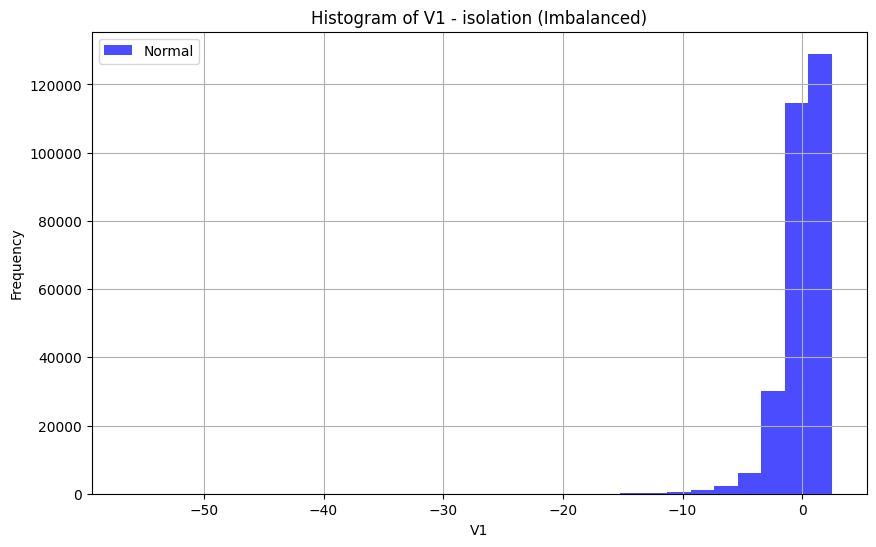

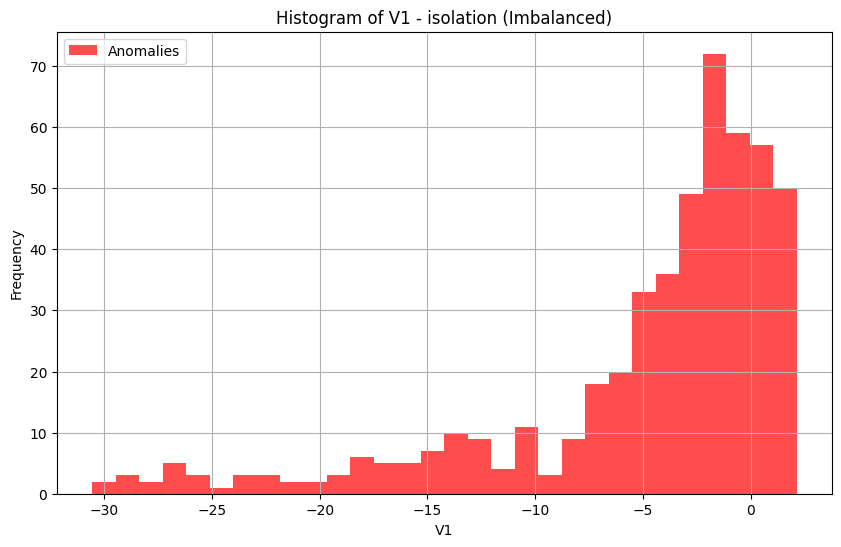

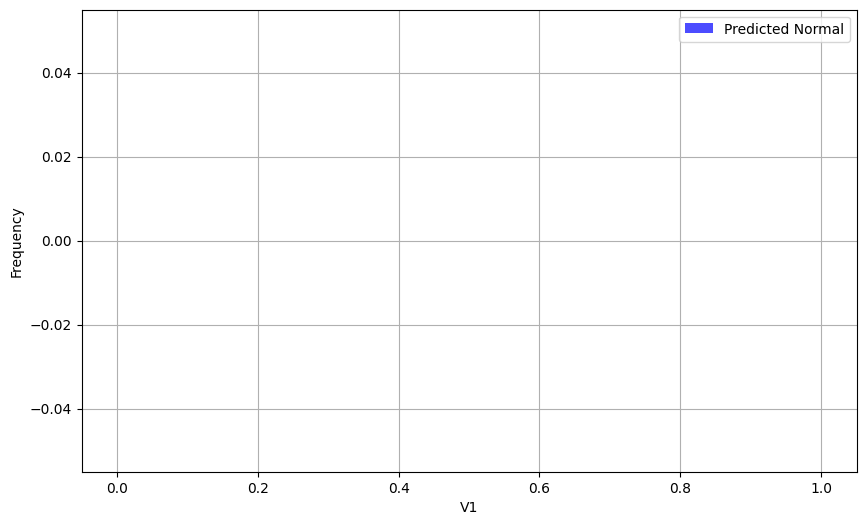

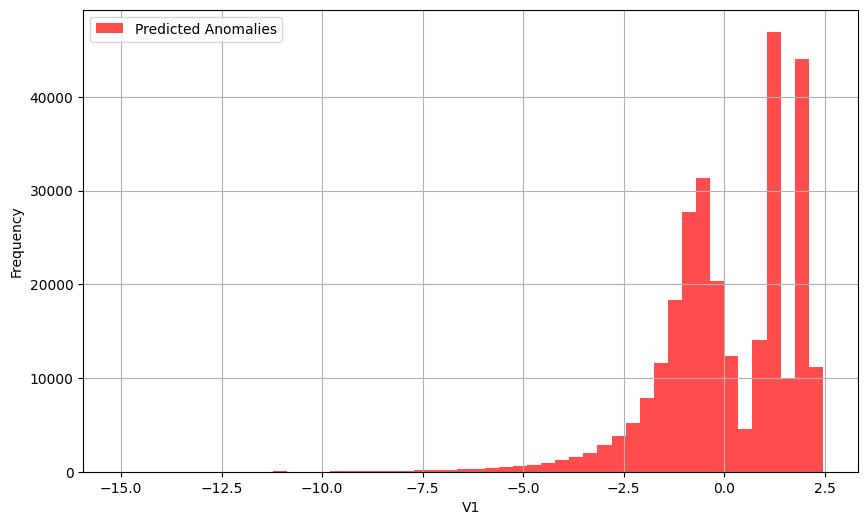

In [41]:
from visualization.histogram_result import HistogramDiffResult

histogram_viz = HistogramDiffResult(data=training
                                    , labels=label
                                    , feature_name='V1'
                                    , model_path=result_folder + 'isolation_forest_model.pkl'
    )

histogram_viz.plot_histogram_data_raw(imbalance=True, save_path=result_folder + 'isolation_forest_raw_histogram.png')

histogram_viz.plot_histogram_prediction(imbalance=True, save_path=result_folder + 'isolation_forest_prediction_histogram.png')

In [43]:
type(y_test)

pandas.Series

In [44]:
prediction = pd.Series(isolation_predictions)

print(type(prediction))

<class 'pandas.Series'>


In [45]:
prediction.value_counts()

False    83630
True      1813
Name: count, dtype: int64

In [46]:
scores_test = pd.Series(isolation_scores)

scores_test[:3]

0    0.144690
1   -0.139809
2   -0.198515
dtype: float64

<Axes: >

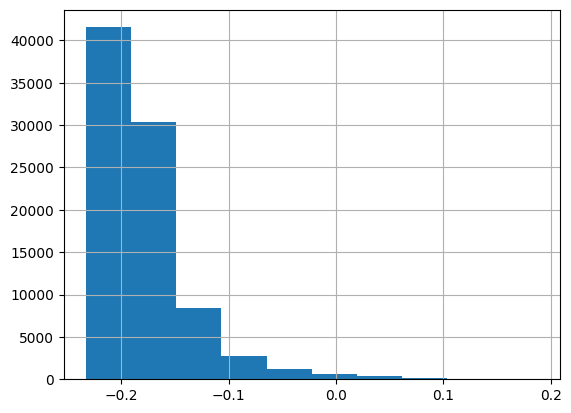

In [47]:
scores_test.hist()

In [ ]:
i_tp = [i for i in range(len(y_test)) if y_test.iloc[i] == 1 and isolation_predictions[i] == 1]
i_fp = [i for i in range(len(y_test)) if y_test.iloc[i] == 0 and isolation_predictions[i] == 1]
i_tn = [i for i in range(len(y_test)) if y_test.iloc[i] == 0 and isolation_predictions[i] == 0]
i_fn = [i for i in range(len(y_test)) if y_test.iloc[i] == 1 and isolation_predictions[i] == 0]


tp = y_test.iloc[i_tp]
tp_score = scores_test.iloc[i_tp]
fp = y_test.iloc[i_fp]
fp_score = scores_test.iloc[i_fp]
tn = y_test.iloc[i_tn]
tn_score = scores_test.iloc[i_tn]   
fn = y_test.iloc[i_fn]
fn_score = scores_test.iloc[i_fn]

print("Len of each category: ")
print(f"TP: {len(tp)}, FP: {len(fp)}, TN: {len(tn)}, FN: {len(fn)}")

Len of each category: 
TP: 106, FP: 1707, TN: 83600, FN: 30


In [49]:
fp_score

32       0.160826
174     -0.040562
252      0.027425
369     -0.045120
431     -0.036839
           ...   
85242   -0.006173
85243    0.031778
85294   -0.029758
85364    0.050201
85424    0.065736
Length: 1707, dtype: float64

In [56]:
max(fp_score), max(tn_score), max(tp_score), max(fn_score)

(0.18739280163326388,
 -0.048679856700983515,
 0.18286431980047257,
 -0.049748401792180874)

In [57]:
min(fp_score), min(tn_score), min(tp_score), min(fn_score)

(-0.04859274975995154,
 -0.23280561369391306,
 -0.04647066259093291,
 -0.2205858838204472)

In [50]:
len(tp_score), len(fp_score), len(tn_score), len(fn_score)

(106, 1707, 83600, 30)

In [51]:
len(scores_test)

85443

Text(0.5, 0, 'Isolation Forest Score')

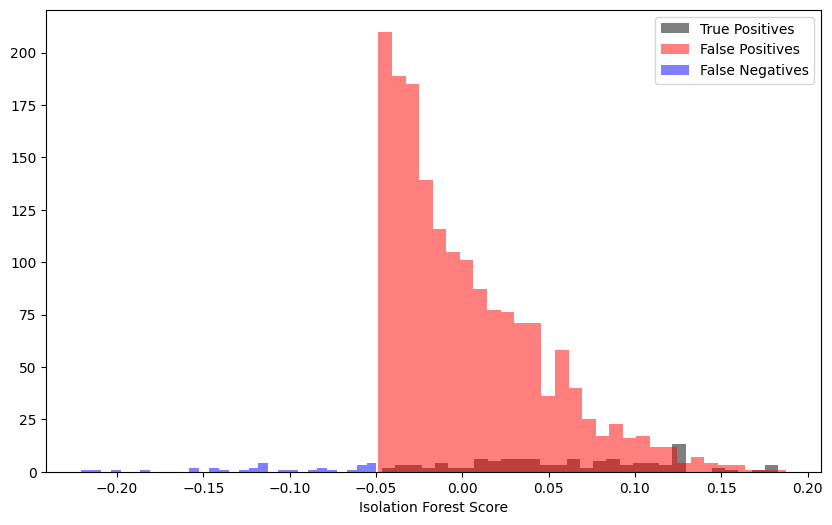

In [52]:
# compare the score distribution of TP, FP, TN, FN
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(tp_score, bins=30, alpha=0.5, label='True Positives', color='black')
plt.hist(fp_score, bins=30, alpha=0.5, label='False Positives', color='red')
# plt.hist(tn_score, bins=30, alpha=0.5, label='True Negatives', color='green')
plt.hist(fn_score, bins=30, alpha=0.5, label='False Negatives', color='blue')

plt.legend()

plt.xlabel('Isolation Forest Score')

Text(0.5, 0, 'Isolation Forest Score Density')

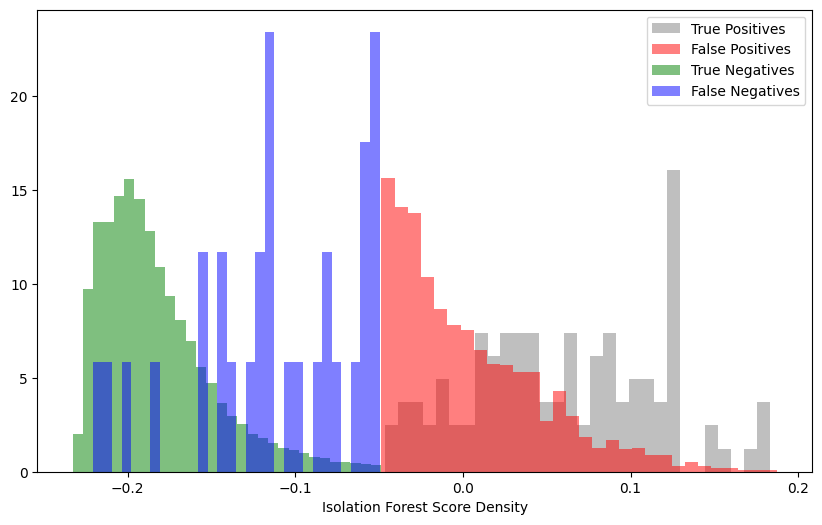

In [53]:
# compare the score distribution of percentage of TP, FP, TN, FN
# stat='percent'
plt.figure(figsize=(10, 6))
plt.hist(tp_score, bins=30, alpha=0.5, label='True Positives', color='grey', density=True)
plt.hist(fp_score, bins=30, alpha=0.5, label='False Positives', color='red', density=True)
plt.hist(tn_score, bins=30, alpha=0.5, label='True Negatives', color='green', density=True)
plt.hist(fn_score, bins=30, alpha=0.5, label='False Negatives', color='blue', density=True)

plt.legend()

plt.xlabel('Isolation Forest Score Density')

In [54]:
threshold = isolation_forest.model.offset_
threshold

np.float64(-0.5753995787074702)

## Test stability of model

In [64]:

def training_and_eval(n_estimator, contamination, random_state):
    print("Start training Isolation Forest model...")
    isolation_forest = IsolationForestDetector(n_estimators=n_estimator, contamination=contamination, random_state=random_state)

    isolation_forest.fit(X_train)

    print("Param model training: ")
    print(f"n_estimator = {n_estimator}, contamination = {contamination}, random_state = {random_state}")
    print("Model training completed.")

    print("Scoring test data...")

    isolation_scores = isolation_forest.score(X_test)

    isolation_predictions = isolation_forest.predict(X_test)

    print("Isolation Forest Scores: ", isolation_scores[:5])
    print("Isolation Forest Predictions: ", isolation_predictions[:5])


    print("Evaluating model performance...")

    if y_test is not None:
        print("Number of anomalies detected: ", np.sum(isolation_predictions))
        print("Percentage of anomalies detected: ", np.mean(isolation_predictions) * 100, "%")
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, isolation_predictions.astype(int)))
        print("\nClassification Report:")
        print(classification_report(y_test, isolation_predictions.astype(int)))

        print("AUC-ROC of isolation forest: ", roc_auc_score(y_test, isolation_scores))

        classification_report_df = classification_report(y_test, isolation_predictions.astype(int), output_dict=True)

        report_df = pd.DataFrame(classification_report_df).transpose()

        return precision_score(y_test, isolation_predictions.astype(int)) \
                , recall_score(y_test, isolation_predictions.astype(int)) \
                , f1_score(y_test, isolation_predictions.astype(int)) \
                , accuracy_score(y_test, isolation_predictions.astype(int))

    else:
        print("No labels available for evaluation.")
        print("Number of detected anomalies: ", np.sum(isolation_predictions))

        return None, None, None, None


In [67]:
res = []

for random_state in [random.randint(1, 100) for _ in range(10)]:
    
    precision, recall, f1, acc = training_and_eval(n_estimator=100, contamination=0.01, random_state=random_state)

    res.append((precision, recall, f1, acc))

res_df = pd.DataFrame(res, columns=['precision', 'recall', 'f1', 'acc'])
res_df
    

Start training Isolation Forest model...
Param model training: 
n_estimator = 100, contamination = 0.01, random_state = 71
Model training completed.
Scoring test data...
Isolation Forest Scores:  [ 0.16038123 -0.13034917 -0.2026909  -0.20606048 -0.22376454]
Isolation Forest Predictions:  [ True False False False False]
Evaluating model performance...
Number of anomalies detected:  1926
Percentage of anomalies detected:  2.2541343351708156 %
Confusion Matrix:
[[83487  1820]
 [   30   106]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85307
           1       0.06      0.78      0.10       136

    accuracy                           0.98     85443
   macro avg       0.53      0.88      0.55     85443
weighted avg       1.00      0.98      0.99     85443

AUC-ROC of isolation forest:  0.9617355206351593
Start training Isolation Forest model...
Param model training: 
n_estimator = 100, contamination = 0.01, r

,precision,recall,f1,acc
0,0.055036,0.779412,0.102813,0.978348
1,0.055336,0.720588,0.102779,0.979975
2,0.049510,0.705882,0.092530,0.977962
3,0.058684,0.727941,0.108612,0.980981
4,0.050748,0.698529,0.094622,0.978723
5,0.052686,0.750000,0.098456,0.978137
6,0.055375,0.750000,0.103134,0.979238
7,0.053292,0.750000,0.099512,0.978395
8,0.058269,0.772059,0.108359,0.979776
9,0.052828,0.727941,0.098507,0.978793


In [68]:
res_df.describe()

,precision,recall,f1,acc
count,10.000000,10.000000,10.000000,10.000000
mean,0.054176,0.738235,0.100932,0.979033
std,0.002962,0.026670,0.005275,0.000958
min,0.049510,0.698529,0.092530,0.977962
25%,0.052722,0.722426,0.098469,0.978360
50%,0.054164,0.738971,0.101146,0.978758
75%,0.055365,0.750000,0.103054,0.979641
max,0.058684,0.779412,0.108612,0.980981


Có thể cân nhắc xem các chỉ số std_f1 / mean_f1   
- Nếu <3% -> tốt
- 3-10% - chấp nhận được
- =>10% - cần xem xét lại, variance đang cao 
